<h1 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    text-align:center;
    font-weight:bold;
    padding:18px 12px;
    border-radius:10px;
    margin-bottom:7px;">
    Day 2 — Text Representation: TF-IDF & Embeddings
</h1>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">
    From Clean Text to Numerical Meaning
</h3>

<div style="
    border-left:6px solid #FB7185;
    background-color:#FFF1F2;
    padding:12px 16px;
    margin:16px 0;
    border-radius:6px;
    color:#7F1D1D;">
    <b>Week 8 — NLP & Computer Vision • Day 2</b><br>
    Dataset: <code>IMDB_Dataset_Cleaned_Day1.csv</code>
</div>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
<p><b>Main question:</b></p>
<div style="
    font-size:1.12em;
    font-weight:bold;
    text-align:center;
    background-color:#FFFBEB;
    border:1px solid #FBBF24;
    padding:16px;
    border-radius:8px;
    margin:14px 0;
    color:#111827;">
    How do we convert the clean text from Day 1 into numbers that a machine learning model can understand?
</div>
</div>

<a id="toc"></a>
<h2 style="color:#92400E; background-color:#FBBF24; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">
Table of Contents
</h2>

<div style="border:1px solid #CBD5E1; padding:16px 25px; border-radius:8px; background-color:#FFFFFF; color:#111827;">
<ul style="font-weight:bold; line-height:1.95; color:#1F2937;">
<li><a href="#section0">0. Setup — Imports & Data Path</a></li>
<li><a href="#section1">1. Day 2 Learning Map</a></li>
<li><a href="#section2">2. Load the Clean Day 1 Dataset</a></li>
<li><a href="#section3">3. From Text to Numbers</a></li>
<li><a href="#section4">4. Bag of Words</a></li>
<li><a href="#section5">5. TF — Term Frequency</a></li>
<li><a href="#section6">6. IDF — Inverse Document Frequency</a></li>
<li><a href="#section7">7. TF-IDF</a></li>
<li><a href="#section8">8. TF-IDF on the Real IMDb Data</a></li>
<li><a href="#section9">9. Vocabulary, Features & Sparse Matrix</a></li>
<li><a href="#section10">10. What TF-IDF Learned from the Reviews</a></li>
<li><a href="#section11">11. Word Embeddings</a></li>
<li><a href="#section12">12. Vector Space & Semantic Similarity</a></li>
<li><a href="#section13">13. Word2Vec & GloVe</a></li>
<li><a href="#section14">14. Contextual Embeddings</a></li>
<li><a href="#section15">15. TF-IDF vs. Embeddings</a></li>
<li><a href="#section16">16. Simple Sentiment Baseline</a></li>
<li><a href="#section17">17. What I Learned Today</a></li>
<li><a href="#section18">18. Day 3 Preview</a></li>
</ul>
</div>

<a id="section0"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    0. Setup — Imports & Data Path
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.1 Coding style used in this notebook</h3>
<p>The code is intentionally simple and readable. It follows the practical style used in
<b>Python for Data Analysis</b>: load tabular data with pandas, inspect the DataFrame,
use NumPy for numeric vectors, visualize with matplotlib, and use scikit-learn through
the familiar <code>fit()</code> / <code>predict()</code> workflow.</p>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Important:</b> The book is a data-analysis book, not an NLP textbook. The pandas / NumPy / Jupyter / scikit-learn coding style comes from the book, while the TF-IDF and embeddings concepts come from the Week 8 Day 2 curriculum.
    </div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">0.2 Folder structure</h3>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Week 8/
└── Day 2/
    ├── Day2.ipynb
    └── IMDB_Dataset_Cleaned_Day1.csv</div>
    </div>

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)

print("Setup complete.")

Setup complete.


In [2]:
# Find the cleaned CSV in the notebook folder first, then /mnt/data.
candidate_paths = [
    Path("IMDB_Dataset_Cleaned_Day1.csv"),
    Path.cwd() / "IMDB_Dataset_Cleaned_Day1.csv",
    Path("/mnt/data/IMDB_Dataset_Cleaned_Day1.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "IMDB_Dataset_Cleaned_Day1.csv was not found. "
        "Place it beside Day2.ipynb."
    )

print("Dataset:", DATA_PATH.resolve())

Dataset: C:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 8\Day 2\IMDB_Dataset_Cleaned_Day1.csv


<a id="section1"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    1. Day 2 Learning Map
</h2>

   <div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <p>Day 1 stopped here:</p>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Raw Review
   ↓
Preprocessing
   ↓
Clean Review</div>


<p>Day 2 continues from that exact point:</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Clean Review
   ↓
Text Representation
   ↓
Numeric Vector
   ↓
Machine Learning Model</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">The two representation families</h3>
<table style="width:100%;border-collapse:collapse;">
<tr style="background-color:#0F766E; color:white;">
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">Frequency-Based</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">Semantic</th>
</tr>
<tr>
<td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Bag of Words / TF-IDF</b><br>Focus on words and their importance.</td>
<td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Word Embeddings</b><br>Focus on meaning and relationships between words.</td>
</tr>
</table>
    </div>

<a id="section2"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    2. Load the Clean Day 1 Dataset
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">2.1 Why we start with the cleaned CSV</h3>
<p>We do <b>not</b> repeat Day 1 preprocessing. The file already contains the original review,
the cleaned review, and the sentiment label.</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">review       → original text
clean_review → Day 1 cleaned text
sentiment    → positive / negative label</div>

<p>Our main input today is <code>clean_review</code>.</p>
    </div>

In [3]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (5000, 3)
Columns: ['review', 'clean_review', 'sentiment']


In [4]:
preview = df[["clean_review", "sentiment"]].head(5).copy()
preview["clean_review"] = preview["clean_review"].str.slice(0, 180) + "..."
preview

,clean_review,sentiment
0,really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslam eve...,positive
1,not many television show appeal quite many different kind fan like farscape know youngster year old fan male female ...,positive
2,film quickly get major chase scene ever increase destruction first really bad thing guy hijack steven seagal would b...,negative
3,jane austen would definitely approve one gwyneth paltrow awesome job capture attitude emma funny without excessively...,positive
4,expectation somewhat high go see movie think steve carell could no wrong come great movie like anchorman virgin litt...,negative


In [5]:
print("Missing values:")
display(df.isna().sum().to_frame("missing"))

print("\nSentiment distribution:")
display(df["sentiment"].value_counts().to_frame("count"))

Missing values:


,missing
review,0
clean_review,0
sentiment,0



Sentiment distribution:


,count
sentiment,
positive,2519
negative,2481


<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <div style="
    border-left:5px solid #0F766E;
    background-color:#CCFBF1;
    padding:11px 15px;
    margin:12px 0;
    border-radius:5px;
    color:#134E4A;">
    <b>Dataset check:</b> The uploaded cleaned dataset contains 5,000 reviews. It is already very close to balanced between positive and negative labels.
</div>
    </div>

<a id="section3"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    3. From Text to Numbers
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.1 Why text must become numeric</h3>
<p>Even after cleaning, this:</p>
    <div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">movie amazing love</div>


<p>is still text. A machine learning model needs numbers:</p>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">[0.12, 0.00, 0.76, 0.41, ...]</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">3.2 Vectorization</h3>
<p><b>Vectorization</b> means converting text into a numeric vector.</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Clean Text
   ↓
Vectorizer
   ↓
Numeric Vector</div>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Remember:</b> Preprocessing prepares the text. Vectorization represents the text numerically.
    </div>
    </div>

<a id="section4"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    4. Bag of Words
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.1 What is Bag of Words?</h3>
<p>Bag of Words represents a document using <b>which words appear</b> and
<b>how many times each word appears</b>. It ignores word order.</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">D1: movie good
D2: movie bad
D3: movie movie good

Vocabulary = [bad, good, movie]</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">4.2 The idea</h3>
<table style="width:100%;border-collapse:collapse;">
<tr style="background-color:#0F766E; color:white;">
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">Document</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">bad</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">good</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">movie</th>
</tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">D1</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">0</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">1</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">1</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">D2</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">1</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">0</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">1</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">D3</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">0</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">1</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">2</td></tr>
</table>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Main limitation:</b> Raw counts do not tell us whether a word is common everywhere or truly distinctive.
    </div>
    </div>

In [6]:
toy_docs = [
    "movie good",
    "movie bad",
    "movie movie good",
]

bow = CountVectorizer()
X_bow = bow.fit_transform(toy_docs)

bow_table = pd.DataFrame(
    X_bow.toarray(),
    columns=bow.get_feature_names_out(),
    index=["D1", "D2", "D3"],
)

bow_table

,bad,good,movie
D1,0,1,1
D2,1,0,1
D3,0,1,2


<a id="section5"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    5. TF — Term Frequency
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.1 Definition</h3>
<p><b>TF (Term Frequency)</b> asks:</p>
    <div style="
        border-left:5px solid #0284C7;
        background-color:#E0F2FE;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#0C4A6E;">
        <b>How frequent is this term inside this one document?</b>
    </div>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Document: movie good good amazing

movie   → 1
good    → 2
amazing → 1</div>


<p>The word <code>good</code> has the highest raw term frequency in this document.</p>
<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">5.2 Bag of Words vs. TF</h3>
<p>They are closely related. Bag of Words is the <b>whole document representation</b>;
TF is the <b>frequency value for one term inside one document</b>.</p>
    </div>

In [7]:
document = "movie good good amazing"
words = document.split()

tf_counts = pd.Series(words).value_counts()
tf_counts.to_frame("raw_tf")

,raw_tf
good,2
movie,1
amazing,1


<a id="section6"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    6. IDF — Inverse Document Frequency
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.1 Definition</h3>
<p><b>IDF</b> looks across the complete collection of documents and asks:</p>
    <div style="
        border-left:5px solid #0284C7;
        background-color:#E0F2FE;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#0C4A6E;">
        <b>Is this word rare and distinctive, or is it common everywhere?</b>
    </div>
    <div style="
        background-color:#FFFBEB;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">movie        → appears in many movie reviews → low IDF
masterpiece  → appears in fewer reviews     → higher IDF</div>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">6.2 Relationship</h3>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Document Frequency ↑  →  IDF ↓
Document Frequency ↓  →  IDF ↑</div>
    </div>

In [8]:
idf_docs = [
    "movie masterpiece",
    "movie good",
    "movie bad",
    "movie amazing",
]

N = len(idf_docs)

terms = ["movie", "masterpiece"]

rows = []
for term in terms:
    document_frequency = sum(term in doc.split() for doc in idf_docs)
    idf = math.log(N / document_frequency)
    rows.append([term, document_frequency, round(idf, 3)])

pd.DataFrame(rows, columns=["term", "document_frequency", "simple_idf"])

,term,document_frequency,simple_idf
0,movie,4,0.000
1,masterpiece,1,1.386


<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <div style="
    border-left:5px solid #FBBF24;
    background-color:#FFFBEB;
    padding:11px 15px;
    margin:12px 0;
    border-radius:5px;
    color:#78350F;">
    <b>Note:</b> The manual IDF above uses the simple teaching formula <code>log(N / df)</code>. Scikit-learn uses smoothing by default, so its exact numeric scores will be slightly different. The idea is the same.
</div>
    </div>

<a id="section7"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    7. TF-IDF
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.1 Combine TF and IDF</h3>
    <div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">TF-IDF = TF × IDF</div>


<p>A word receives a strong TF-IDF score when it is:</p>
<ul>
<li>important inside the current document, <b>and</b></li>
<li>not common across every document.</li>
</ul>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.2 Intuition</h3>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">movie
→ may appear often
→ but appears in many reviews
→ lower TF-IDF importance

masterpiece
→ may appear less often
→ but is more distinctive
→ higher TF-IDF importance</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">7.3 Limitation</h3>
<p>TF-IDF is excellent at measuring <b>word importance</b>, but it does not understand
that words such as <code>good</code>, <code>great</code>, and <code>excellent</code> are semantically related.</p>
    </div>

In [9]:
toy_tfidf = TfidfVectorizer()
X_toy_tfidf = toy_tfidf.fit_transform(idf_docs)

toy_tfidf_table = pd.DataFrame(
    X_toy_tfidf.toarray(),
    columns=toy_tfidf.get_feature_names_out(),
    index=["D1", "D2", "D3", "D4"],
).round(3)

toy_tfidf_table

,amazing,bad,good,masterpiece,movie
D1,0.000,0.000,0.000,0.887,0.463
D2,0.000,0.000,0.887,0.000,0.463
D3,0.000,0.887,0.000,0.000,0.463
D4,0.887,0.000,0.000,0.000,0.463


<a id="section8"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    Hands On Lab Start From Here
</h2>

<a id="section8"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    8. TF-IDF on the Real IMDb Data
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">8.1 Use the Day 1 clean_review column</h3>
<p>Now we stop using toy examples and vectorize the real cleaned reviews.</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">df["clean_review"]
        ↓
TfidfVectorizer(max_features=5000)
        ↓
X_tfidf</div>


<p><code>max_features=5000</code> keeps the representation simple enough to inspect while still using a useful vocabulary.</p>
    </div>

In [10]:
texts = df["clean_review"]

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(texts)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (5000, 5000)


In [11]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 30 features:")
print(feature_names[:30])

Number of features: 5000
First 30 features:
['abandon' 'abbott' 'abc' 'ability' 'able' 'abraham' 'abrupt' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'abuse' 'abusive' 'abysmal'
 'academy' 'accent' 'accept' 'acceptable' 'access' 'accident' 'accidental'
 'accidentally' 'acclaim' 'accompany' 'accomplish' 'accord' 'account'
 'accurate' 'accuse']


<a id="section9"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    9. Vocabulary, Features & Sparse Matrix
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.1 Vocabulary</h3>
<p>Each term selected by the vectorizer becomes one <b>feature</b>.</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Vocabulary:
[acting, amazing, bad, ... , story]

One column = one feature</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.2 Matrix structure</h3>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Rows    = reviews
Columns = vocabulary terms / features
Values  = TF-IDF scores</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">9.3 Why is it sparse?</h3>
<p>A single review contains only a small part of the 5,000-word vocabulary,
so most matrix values are zero.</p>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Sparse matrix = a matrix in which most values are zero.</b>
    </div>
    </div>

In [12]:
total_values = X_tfidf.shape[0] * X_tfidf.shape[1]
non_zero_values = X_tfidf.nnz
density = non_zero_values / total_values

print("Total possible values :", f"{total_values:,}")
print("Non-zero values       :", f"{non_zero_values:,}")
print("Matrix density        :", f"{density:.4%}")
print("Matrix sparsity       :", f"{1 - density:.4%}")

Total possible values : 25,000,000
Non-zero values       : 397,463
Matrix density        : 1.5899%
Matrix sparsity       : 98.4101%


In [13]:
# Small readable preview only
preview_rows = 5
preview_cols = 12

pd.DataFrame(
    X_tfidf[:preview_rows, :preview_cols].toarray(),
    columns=feature_names[:preview_cols],
    index=[f"Review_{i+1}" for i in range(preview_rows)],
).round(3)

,abandon,abbott,abc,ability,able,abraham,abrupt,absence,absent,absolute,absolutely,absurd
Review_1,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Review_2,0.0,0.0,0.0,0.0,0.062,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Review_3,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Review_4,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Review_5,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<a id="section10"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    10. What TF-IDF Learned from the Reviews
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">10.1 Highest-weight terms in one review</h3>
<p>Instead of looking at all 5,000 features, we can inspect the terms with the largest TF-IDF scores for a single review.</p>
    </div>

In [14]:
review_index = 0

row = X_tfidf[review_index].toarray().ravel()
top_positions = row.argsort()[::-1][:12]

top_terms = pd.DataFrame({
    "term": feature_names[top_positions],
    "tfidf_score": row[top_positions],
})

print("Sentiment:", df.loc[review_index, "sentiment"])
print("\nClean review preview:")
print(df.loc[review_index, "clean_review"][:450], "...")
print()
display(top_terms.round(4))

Sentiment: positive

Clean review preview:
really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslam ever wwf not lex luger main event yokozuna time ok huge fat man v strong man glad time change terrible main event like every match luger terrible match card razor ramon v ted dibiase steiner brother vs heavenly body shawn michael vs curt hening event shawn name big monster body guard diesel irs vs kid bret hart first take doink take je ...



,term,tfidf_score
0,match,0.4124
1,terrible,0.3190
2,hart,0.2859
3,bam,0.2824
4,event,0.2526
5,take,0.1902
6,body,0.1711
7,ramon,0.1493
8,main,0.1483
9,marty,0.1429


<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">10.2 Average important terms by sentiment</h3>
<p>We can also average TF-IDF scores inside each sentiment class to see which terms are more prominent in positive or negative reviews.</p>
    </div>

In [15]:
labels = df["sentiment"].to_numpy()

positive_mean = np.asarray(X_tfidf[labels == "positive"].mean(axis=0)).ravel()
negative_mean = np.asarray(X_tfidf[labels == "negative"].mean(axis=0)).ravel()

positive_top = positive_mean.argsort()[::-1][:15]
negative_top = negative_mean.argsort()[::-1][:15]

positive_terms = pd.DataFrame({
    "positive_term": feature_names[positive_top],
    "avg_tfidf": positive_mean[positive_top],
})

negative_terms = pd.DataFrame({
    "negative_term": feature_names[negative_top],
    "avg_tfidf": negative_mean[negative_top],
})

display(pd.concat([positive_terms, negative_terms], axis=1).round(4))

,positive_term,avg_tfidf,negative_term,avg_tfidf
0,film,0.0597,movie,0.0727
1,movie,0.0581,not,0.0720
2,not,0.0503,film,0.0540
3,one,0.0335,bad,0.0412
4,see,0.0312,one,0.0322
5,great,0.0286,like,0.0315
6,like,0.0266,make,0.0310
7,good,0.0264,get,0.0289
8,make,0.0262,see,0.0286
9,love,0.0244,good,0.0274


<a id="section11"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    11. Word Embeddings
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.1 What changes with embeddings?</h3>
<p>TF-IDF represents <b>importance</b>. Word embeddings try to represent <b>meaning</b>.</p>
    <div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">TF-IDF:
good → a score in a document

Embedding:
good → [0.21, -0.43, 0.87, 0.15, ...]</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">11.2 Dense vectors</h3>
<table style="width:100%;border-collapse:collapse;">
<tr style="background-color:#0F766E; color:white;">
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">TF-IDF</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">Embedding</th>
</tr>
<tr>
<td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Sparse: many zeros</td>
<td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Dense: many dimensions contain values</td>
</tr>
<tr>
<td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Document-word importance</td>
<td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Semantic word representation</td>
</tr>
</table>
    </div>

<a id="section12"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    12. Vector Space & Semantic Similarity
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">12.1 The main idea</h3>
<p>Words with similar meanings should be close to each other in an embedding space.</p>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">good      ≈ great      ≈ excellent
bad       ≈ terrible   ≈ awful</div>


<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">12.2 Cosine similarity</h3>
<p>A common way to compare vectors is <b>cosine similarity</b>. A higher value means the vectors point in more similar directions.</p>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>The vectors below are illustrative teaching vectors only.</b> They are not learned Word2Vec or GloVe values.
    </div>
    </div>

In [16]:
# Illustrative dense vectors only
word_vectors = {
    "good": np.array([0.9, 0.8]),
    "great": np.array([0.85, 0.78]),
    "bad": np.array([-0.8, -0.9]),
    "terrible": np.array([-0.85, -0.82]),
}

good_vs_great = cosine_similarity(
    [word_vectors["good"]],
    [word_vectors["great"]]
)[0, 0]

good_vs_bad = cosine_similarity(
    [word_vectors["good"]],
    [word_vectors["bad"]]
)[0, 0]

print("Similarity(good, great):", round(good_vs_great, 3))
print("Similarity(good, bad)  :", round(good_vs_bad, 3))

Similarity(good, great): 1.0
Similarity(good, bad)  : -0.993


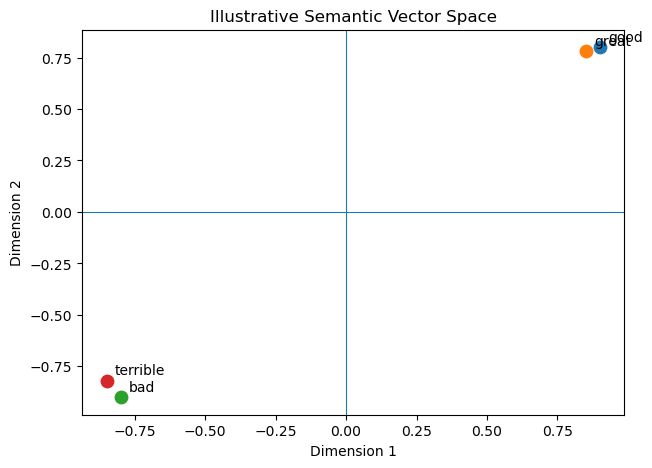

In [17]:
plt.figure(figsize=(7, 5))

for word, vector in word_vectors.items():
    plt.scatter(vector[0], vector[1], s=80)
    plt.text(vector[0] + 0.03, vector[1] + 0.03, word)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Illustrative Semantic Vector Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

<a id="section13"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    13. Word2Vec & GloVe
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">13.1 Word2Vec</h3>
<p><b>Word2Vec</b> is a classic method for learning word embeddings from the context in which words appear.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">13.2 GloVe</h3>
<p><b>GloVe</b> is another classic embedding method. It learns vector relationships from global word co-occurrence information.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">13.3 What matters today</h3>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Word2Vec / GloVe
        ↓
Word
        ↓
Dense Vector
        ↓
Semantic relationships</div>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>For Day 2 understanding:</b> You do not need to derive the Word2Vec or GloVe training algorithms. You need to understand what they produce and why those vectors are useful.
    </div>
    </div>

<a id="section14"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    14. Contextual Embeddings
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">14.1 The limitation of fixed embeddings</h3>
<p>Traditional Word2Vec-style embeddings usually give one fixed vector to a word.</p>

<p>But consider:</p>
    <div style="
        background-color:#FFF7ED;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">I deposited money in the bank.
We sat beside the river bank.</div>


<p>The word <code>bank</code> has a different meaning in each sentence.</p>

<h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">14.2 Contextual solution</h3>
<p>Contextual embeddings from transformer models can generate a different vector for the same word depending on the sentence around it.</p>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">bank + financial context → vector A
bank + river context     → vector B</div>
    </div>

<a id="section15"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    15. TF-IDF vs. Embeddings
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <table style="width:100%;border-collapse:collapse;">
<tr style="background-color:#0F766E; color:white;">
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">Question</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">TF-IDF</th>
<th style="color:white;padding:9px;border:1px solid #CBD5E1;">Embeddings</th>
</tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>What does it represent?</b></td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Word importance</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Word meaning</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Main idea</b></td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Frequency + rarity</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Semantic geometry</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Vector type</b></td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Sparse</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Dense</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Understands similar words?</b></td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">No, not directly</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Yes, semantically</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Understands context?</b></td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">No</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Contextual embeddings can</td></tr>
<tr><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;"><b>Best role</b></td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Simple, strong baseline</td><td style="padding:9px;border:1px solid #CBD5E1;background:#FFFFFF;color:#111111;">Semantic and deep-learning tasks</td></tr>
</table>
    <div style="
        border-left:5px solid #0F766E;
        background-color:#CCFBF1;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#134E4A;">
        <b>Memory sentence:</b> TF-IDF tells us how important a word is. Embeddings try to represent what the word means.
    </div>
    </div>

<a id="section16"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    16. Simple Sentiment Baseline
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <h3 style="background-color:#F8EEEE;color:#7F1D1D;border:1px solid #D9B9BE;border-left:6px solid #7F1D1D;border-radius:8px;padding:9px 12px;margin:18px 0 12px 0;font-size:1.35em;font-weight:800;line-height:1.35;">16.1 Why build a baseline?</h3>
<p>The Day 2 representation is useful only if a model can learn from it. We will therefore use a very simple
<b>Logistic Regression</b> classifier.</p>
    <div style="
        background-color:#E0F2FE;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">clean_review
   ↓
TF-IDF
   ↓
Train / Test Split
   ↓
Logistic Regression
   ↓
Prediction</div>


<p>The modeling code intentionally follows the simple scikit-learn style:
create a model → <code>fit()</code> → <code>predict()</code>.</p>
    </div>

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=df["sentiment"],
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 4000
Testing rows : 1000


In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.856

              precision    recall  f1-score   support

    negative       0.87      0.83      0.85       496
    positive       0.84      0.88      0.86       504

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <div style="
    border-left:5px solid #FBBF24;
    background-color:#FFFBEB;
    padding:11px 15px;
    margin:12px 0;
    border-radius:5px;
    color:#78350F;">
    <b>Interpretation:</b> This model is a baseline, not the final goal of Day 2. The important learning point is that TF-IDF turned text into numeric features that a standard classifier could use.
</div>
    </div>

<a id="section17"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    17. What I Learned Today
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <ul>
<li><b>Text Representation:</b> Clean text must become numeric before a model can use it.</li>
<li><b>Bag of Words:</b> Represents a document using word counts while ignoring order.</li>
<li><b>TF:</b> Measures how frequent a term is inside one document.</li>
<li><b>IDF:</b> Measures how rare or common the term is across all documents.</li>
<li><b>TF-IDF:</b> Combines local frequency with global rarity.</li>
<li><b>Vocabulary:</b> The selected terms become model features.</li>
<li><b>Sparse Matrix:</b> Most TF-IDF entries are zero.</li>
<li><b>Word Embeddings:</b> Dense vectors can represent semantic relationships.</li>
<li><b>Vector Space:</b> Similar meanings can be represented by nearby vectors.</li>
<li><b>Word2Vec & GloVe:</b> Classic methods for creating word embeddings.</li>
<li><b>Contextual Embeddings:</b> A word representation can change according to sentence context.</li>
<li><b>TF-IDF vs. Embeddings:</b> Importance versus meaning.</li>
<li><b>Practical Result:</b> The cleaned IMDb reviews can be vectorized and used by a classifier.</li>
</ul>
    </div>

<a id="section18"></a>
<h2 style="
    color:#FFFFFF;
    background:linear-gradient(90deg,#0F766E,#0284C7);
    font-weight:bold;
    margin-top:30px;
    padding:10px 15px;
    border-radius:8px;">
    18. Day 3 Preview
</h2>

<div style="background-color:#F8F8F8;color:#111111;border:1px solid #E9E9E9;border-radius:9px;padding:16px 18px;margin:10px 0 18px 0;line-height:1.7;">
    <p>Day 2 represented <b>text</b> numerically. Day 3 moves to a different data type: <b>images</b>.</p>
    <div style="
        background-color:#CCFBF1;
        color:#111827;
        padding:12px 14px;
        border-radius:8px;
        border:1px solid #CBD5E1;
        font-family:Consolas, 'Courier New', monospace;
        font-size:0.98em;
        font-weight:600;
        line-height:1.6;
        white-space:pre-wrap;
        margin:10px 0;">Day 1 → Clean Text
Day 2 → TF-IDF & Embeddings
Day 3 → Computer Vision Preprocessing with OpenCV</div>
    <div style="
        border-left:5px solid #FBBF24;
        background-color:#FFFBEB;
        padding:11px 15px;
        margin:12px 0;
        border-radius:5px;
        color:#78350F;">
        <b>Next question:</b> If images are also data, how do we standardize and prepare them before a computer vision model sees them?
    </div>
    </div>

<div style="text-align:center; margin-top:28px; color:#475569;">
<b>End of Day 2 — Text Representation: TF-IDF & Embeddings</b><br>
Clean IMDb data → Numeric representation → Simple sentiment baseline
</div>